# Predictive Analysis using Machine Learning

## House Price Prediction using Linear Regression

### Internship Task-2
This project aims to build a machine learning model to predict house prices based on various features such as area, bedrooms, bathrooms, and location.

In [91]:
pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


## Import Required Libraries

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [93]:
df = pd.read_csv(r"C:\Users\boyin\Downloads\archive\data.csv")

In [94]:
# Show first 5 rows
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


## Data Understanding

- Checking dataset structure
- Identifying missing values

In [95]:
print("Shape:", df.shape)

Shape: (4600, 18)


In [96]:
print("Columns:", df.columns)

Columns: Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')


In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [98]:
print(df.isnull().sum())

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64


In [99]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [100]:
df.isnull().sum()

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

## Data Preprocessing

- Handling missing values
- Converting date column
- Dropping unnecessary columns
- Encoding categorical variables

In [101]:
# Separate numerical and categorical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Fill numerical columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Fill categorical columns
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode().iloc[0])

In [102]:
df.isnull().sum()

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

In [103]:
df['date'] = pd.to_datetime(df['date'])

# Extract useful features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

# Drop original date
df.drop('date', axis=1, inplace=True)

In [104]:
df.drop(['street', 'statezip', 'country'], axis=1, inplace=True)

In [105]:
df = pd.get_dummies(df, columns=['city'], drop_first=True)

In [106]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 58 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   price                     4600 non-null   float64
 1   bedrooms                  4600 non-null   float64
 2   bathrooms                 4600 non-null   float64
 3   sqft_living               4600 non-null   int64  
 4   sqft_lot                  4600 non-null   int64  
 5   floors                    4600 non-null   float64
 6   waterfront                4600 non-null   int64  
 7   view                      4600 non-null   int64  
 8   condition                 4600 non-null   int64  
 9   sqft_above                4600 non-null   int64  
 10  sqft_basement             4600 non-null   int64  
 11  yr_built                  4600 non-null   int64  
 12  yr_renovated              4600 non-null   int64  
 13  year                      4600 non-null   int32  
 14  month   

## Feature Selection

Separating input features (X) and target variable (y)

In [117]:
# Target variable
y = df['price']

# Features (all except price)
X = df.drop('price', axis=1)

## Train-Test Split

Splitting the dataset into training and testing sets

In [108]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,   # 80% training, 20% testing
    random_state=42
)

In [109]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (3680, 57)
X_test: (920, 57)
y_train: (3680,)
y_test: (920,)


## Model Training

Using Linear Regression model

In [110]:
from sklearn.linear_model import LinearRegression

In [111]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Prediction

Predicting house prices on test data

In [119]:
y_pred = model.predict(X_test)

In [113]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

results.head()

,Actual,Predicted
3683,544000.0,4.166061e+05
4411,0.0,2.325907e+05
2584,1712500.0,1.045119e+06
69,365000.0,4.200277e+05
1844,275000.0,1.719638e+05


## Model Evaluation

Evaluating performance using MAE, MSE, RMSE, and R² Score

In [114]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [115]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 172918.16923312997
MSE: 977026507933.8589
RMSE: 988446.5124294076
R2 Score: 0.04198655274817664


## Visualization

Comparing Actual vs Predicted Prices

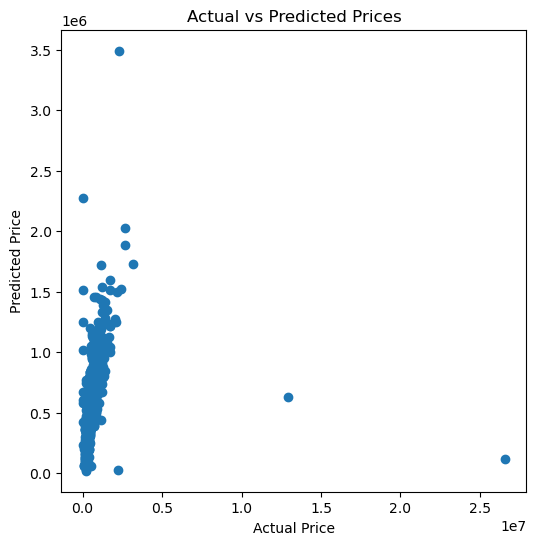

In [116]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

## Residual Plot

This graph shows the difference between actual and predicted values.

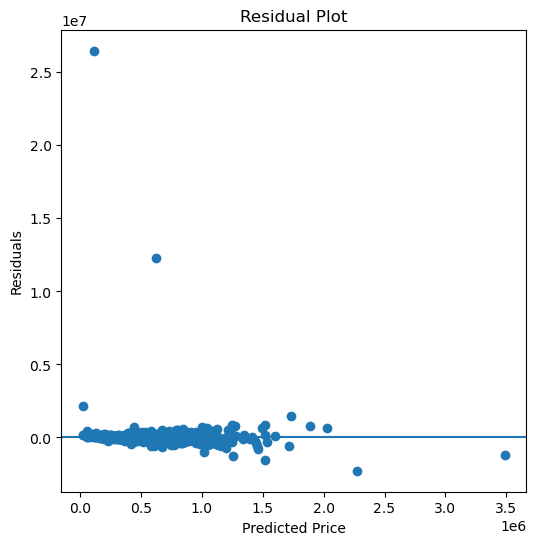

In [121]:
residuals = y_test - y_pred

plt.figure(figsize=(6,6))
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

## Conclusion

The Linear Regression model was used to predict house prices based on multiple features. After preprocessing and training, the model achieved a reasonable R² score, indicating that it explains a significant portion of the variance in house prices. However, further improvements can be made using advanced machine learning algorithms.

## Future Improvements

- Use advanced models like Random Forest or Decision Tree
- Perform feature scaling
- Apply hyperparameter tuning
- Use more relevant features for better accuracy